# Forecasting an InSAR time series: sample-data training notebook


This self-contained copy of the presentation notebook uses the exact synthetic
signal from `cnn_insar_univariate_forecasting.ipynb`. It retains the TensorFlow/Keras
Conv1D–LSTM model and trains it here before generating predictions. No CSV or
previously saved model is needed. Results on synthetic data are illustrative.


## Requirements

Use a Python kernel with `numpy`, `pandas`, `matplotlib`, and `tensorflow`.
If packages are missing, run `%pip install numpy pandas matplotlib tensorflow`
in a separate cell and restart the kernel. CPU training is sufficient.


## Imports and reproducibility


In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf


I0000 00:00:1790348664.789071   30904 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790348666.432976   30904 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
SEED = 42
tf.keras.utils.set_random_seed(SEED)
print(f"TensorFlow {tf.__version__}; pandas {pd.__version__}")


TensorFlow 2.21.0; pandas 3.0.6


The seed fixes the sample data. Training results can still vary between devices and library versions.


## Hyperparameters


In [3]:
window_size = 10
batch_size = 32
shuffle_buffer = 1000
num_epochs = 400
learning_rate = 1e-3


## Generate sample data

540 observations at six-day intervals: a velocity trend, annual oscillation,
a later velocity change, and measurement noise. The resulting DataFrame has
one `ground_motion_mm` column and a `DatetimeIndex` named `date`.


In [4]:
n_example = 540
dates = pd.date_range("2017-01-01", periods=n_example, freq="6D")
elapsed_days = (dates - dates[0]).days.to_numpy()
rng = np.random.default_rng(SEED)
displacement = (
    -2.2 * elapsed_days / 365.25
    + 3.0 * np.sin(2 * np.pi * elapsed_days / 365.25 + 0.3)
    - 1.0 * np.maximum(elapsed_days - 1650, 0) / 365.25
    + rng.normal(0, 0.65, n_example)
)
df = pd.DataFrame({"ground_motion_mm": displacement}, index=dates)
df.index.name = "date"
df.head()


,ground_motion_mm
date,
2017-01-01,1.084627
2017-01-07,0.465002
2017-01-13,1.870687
2017-01-19,2.220674
2017-01-25,0.549265


## Adapt the generated DataFrame

Acquisition dates now come from the row index rather than date-named columns.
The sample is already regularly spaced, so no interpolation is necessary.


In [5]:
if not isinstance(df.index, pd.DatetimeIndex) or df.shape[1] != 1:
    raise ValueError("Expected one displacement column and a DatetimeIndex.")
if df.index.hasnans or df.index.has_duplicates:
    raise ValueError("Dates must be valid and unique.")
df = df.sort_index()
this_ts = pd.to_numeric(df.iloc[:, 0], errors="raise")
if not np.isfinite(this_ts.to_numpy()).all():
    raise ValueError("Displacements must be finite.")
dt_dats = df.index.to_numpy(dtype="datetime64[D]")


In [6]:
if len(dt_dats) < 2 or not np.all(np.diff(dt_dats) == np.timedelta64(6, 'D')):
    raise ValueError("This example expects regular six-day observations.")
dt_dats_padded = dt_dats.copy()
dt_dats_asDays = (dt_dats - dt_dats[0]) / np.timedelta64(1, 'D')
dt_dats_asDays_padded = dt_dats_asDays.copy()
print(f"{len(dt_dats)} acquisitions, spaced six days apart")


540 acquisitions, spaced six days apart


In [7]:
# There are no metadata values to prepend and no missing dates to fill.
this_ts_padded = this_ts.to_numpy(dtype=np.float32)
this_ps_padded = this_ts_padded.copy()


## Plot Observed Data

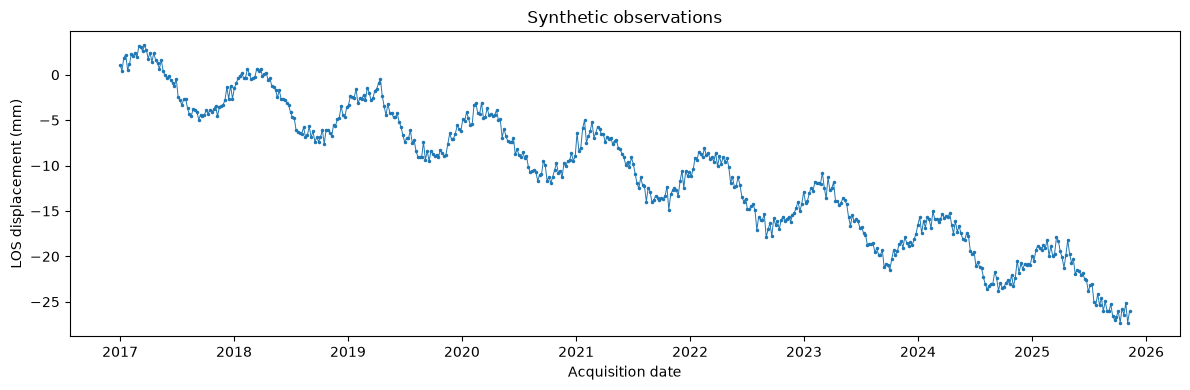

In [8]:
plt.rcParams['figure.facecolor'] = 'white'
plt.figure(figsize=(12, 4))
plt.plot(dt_dats, this_ts_padded, '.-', markersize=3, linewidth=0.7)
plt.xlabel('Acquisition date')
plt.ylabel('LOS displacement (mm)')
plt.title('Synthetic observations')
plt.tight_layout()
plt.show()


## Prepare the modelling signal

Use the noisy observations directly. Whole-series detrending and the original
forward/backward smoothing are omitted because they use future observations.
Standardization below uses only the training segment.


In [9]:
this_signal = this_ps_padded.copy()


In [10]:
time = dt_dats_asDays_padded


In [11]:
print(f"Signal shape: {this_signal.shape}; window: {window_size} acquisitions")


Signal shape: (540,); window: 10 acquisitions


In [12]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    """Make one-step examples: a history window and its next observation."""
    values = np.asarray(series, dtype=np.float32)
    if values.ndim != 1 or len(values) <= window_size:
        raise ValueError("Provide a 1D series longer than the input window.")
    windows = np.lib.stride_tricks.sliding_window_view(values, window_size + 1)
    dataset = tf.data.Dataset.from_tensor_slices(
        (windows[:, :-1].copy(), windows[:, -1].copy())
    )
    return dataset.shuffle(shuffle_buffer, seed=SEED).batch(batch_size).prefetch(1)


## Split the dataset chronologically

Keep the original split at acquisition 340. The final 200 observations are held
out from training and scaling. The epoch count is fixed in advance; this segment
is not used to select epochs.


In [13]:
split_time = 340
if not window_size < split_time < len(this_signal):
    raise ValueError("The split must leave training windows and validation observations.")
time_train, time_valid = time[:split_time], time[split_time:]
x_train, x_valid = this_signal[:split_time], this_signal[split_time:]
train_mean = float(x_train.mean())
train_scale = max(float(x_train.std()), 1e-6)
x_train_scaled = (x_train - train_mean) / train_scale


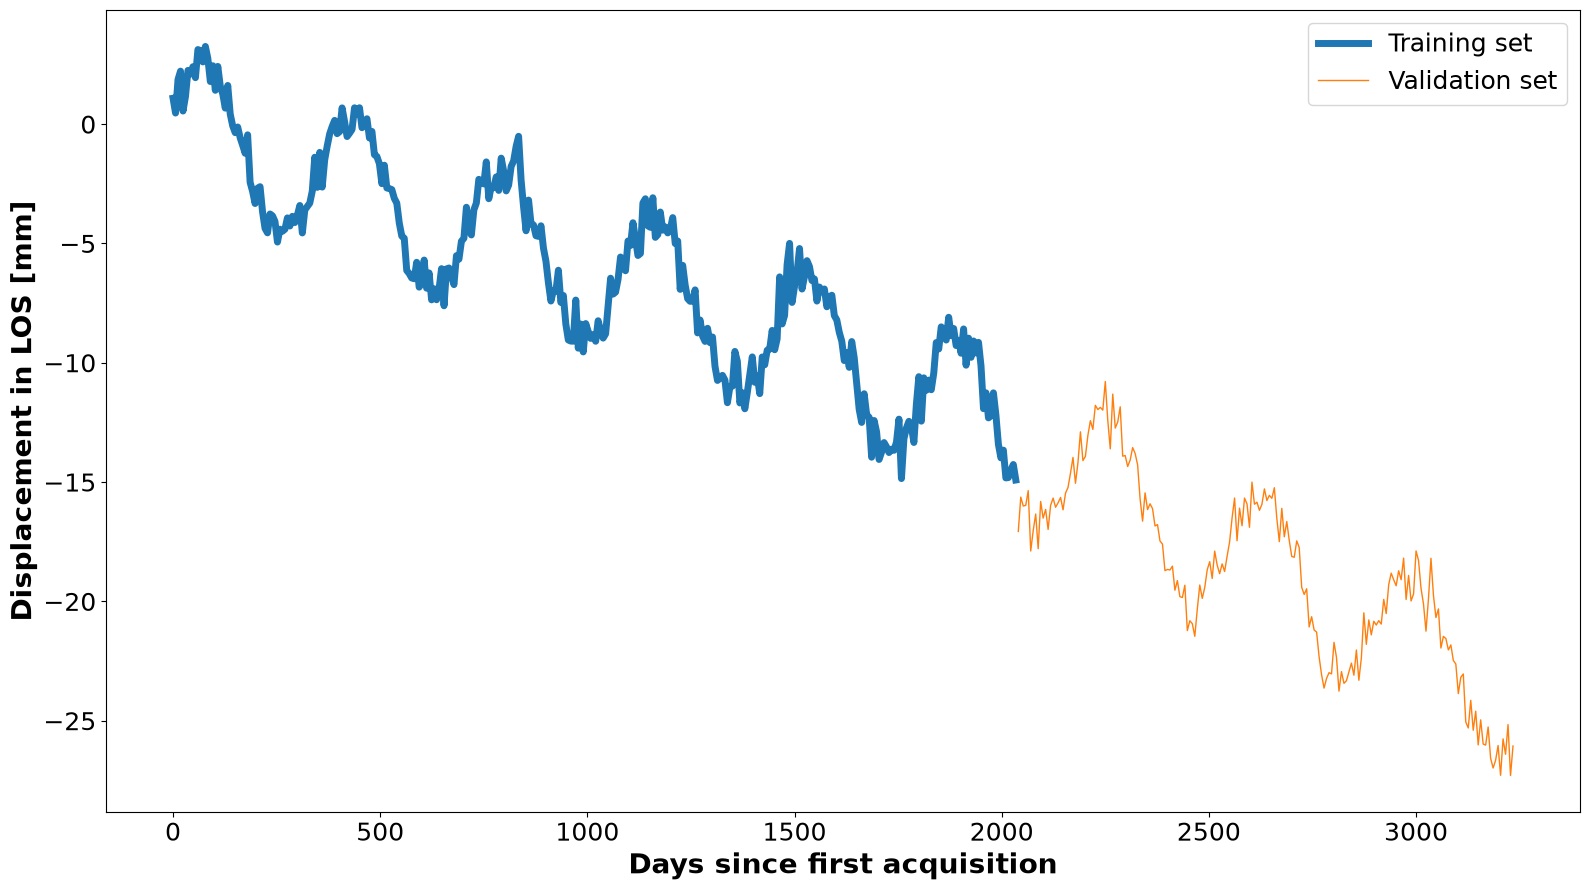

In [14]:
# Plot the train set
plt.figure(figsize=[16,9])
plt.plot(time_train, x_train, linewidth=5, label='Training set')
plt.plot(time_valid, x_valid, linewidth=1, label='Validation set')
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Days since first acquisition', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()


In [15]:
train_set = windowed_dataset(x_train_scaled, window_size, batch_size, shuffle_buffer)


E0000 00:00:1790348667.706156   30904 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# The AI-part

## Build the original Conv1D–LSTM model

The model predicts one standardized displacement from ten past observations.
The architecture retains the original two 64-unit LSTMs and output multiplier.
Building this model initializes new weights; training below is required.


In [16]:
# Reset states generated by Keras
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(window_size, 1)),
    tf.keras.layers.Conv1D(
        filters=64,
        kernel_size=3,
        strides=1,
        padding="causal",
        activation="relu",
    ),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(1),
    tf.keras.layers.Lambda(lambda x: x * 20.),
])


Training starts from scratch; there is no saved-model dependency.


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 10, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,369 (259.25 KB)

 Trainable params: 66,369 (259.25 KB)

 Non-trainable params: 0 (0.00 B)

## Train before predicting


Epoch 1/400


/media/hog/fringe/dev/env/py_general/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


11/11 - 3s - 279ms/step - loss: 0.3287
Epoch 2/400
11/11 - 0s - 9ms/step - loss: 0.1653
Epoch 3/400
11/11 - 0s - 10ms/step - loss: 0.1109
Epoch 4/400
11/11 - 0s - 10ms/step - loss: 0.0690
Epoch 5/400
11/11 - 0s - 10ms/step - loss: 0.0566
Epoch 6/400
11/11 - 0s - 9ms/step - loss: 0.0376
Epoch 7/400
11/11 - 0s - 9ms/step - loss: 0.0390
Epoch 8/400
11/11 - 0s - 9ms/step - loss: 0.0380
Epoch 9/400
11/11 - 0s - 9ms/step - loss: 0.0384
Epoch 10/400
11/11 - 0s - 9ms/step - loss: 0.0345
Epoch 11/400
11/11 - 0s - 9ms/step - loss: 0.0345
Epoch 12/400
11/11 - 0s - 9ms/step - loss: 0.0414
Epoch 13/400
11/11 - 0s - 9ms/step - loss: 0.0454
Epoch 14/400
11/11 - 0s - 9ms/step - loss: 0.0419
Epoch 15/400
11/11 - 0s - 9ms/step - loss: 0.0376
Epoch 16/400
11/11 - 0s - 9ms/step - loss: 0.0420
Epoch 17/400
11/11 - 0s - 9ms/step - loss: 0.0385
Epoch 18/400
11/11 - 0s - 9ms/step - loss: 0.0387
Epoch 19/400
11/11 - 0s - 9ms/step - loss: 0.0331
Epoch 20/400
11/11 - 0s - 9ms/step - loss: 0.0342
Epoch 21/400
11/

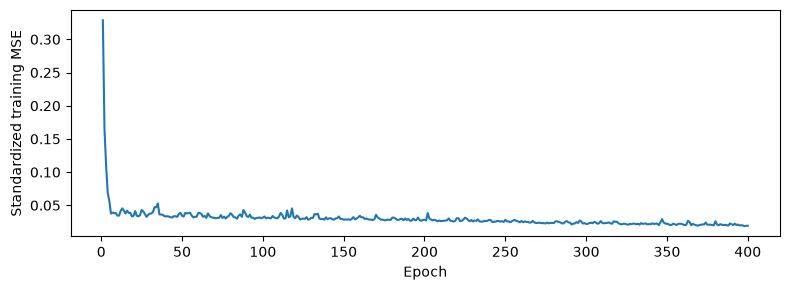

In [18]:
train_set_3d = train_set.map(
    lambda x, y: (x[..., tf.newaxis], y[..., tf.newaxis])
)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0),
    loss="mse",
)
history = model.fit(train_set_3d, epochs=num_epochs, verbose=2)

plt.figure(figsize=(8, 3))
plt.plot(np.arange(1, num_epochs + 1), history.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Standardized training MSE')
plt.tight_layout()
plt.show()


## Rolling one-step forecasts

Each input contains the actual observations immediately before its target date.
The first input is `this_signal[330:340]` and predicts observation 340.
Later inputs may include validation observations already available at that origin.
Predictions are converted back to millimetres before plotting or scoring.


In [19]:
def predict_windows(windows):
    windows = np.asarray(windows, dtype=np.float32)
    if windows.ndim != 2 or windows.shape[1] != window_size:
        raise ValueError(f"Expected [batch, {window_size}] windows.")
    inputs = ((windows - train_mean) / train_scale)[..., None]
    predictions = model(inputs, training=False).numpy().reshape(-1)
    return predictions * train_scale + train_mean

forecast_series = this_signal[split_time - window_size:]
forecast_windows = np.lib.stride_tricks.sliding_window_view(
    forecast_series, window_size + 1
)[:, :-1].copy()
results = predict_windows(forecast_windows)
assert results.shape == x_valid.shape


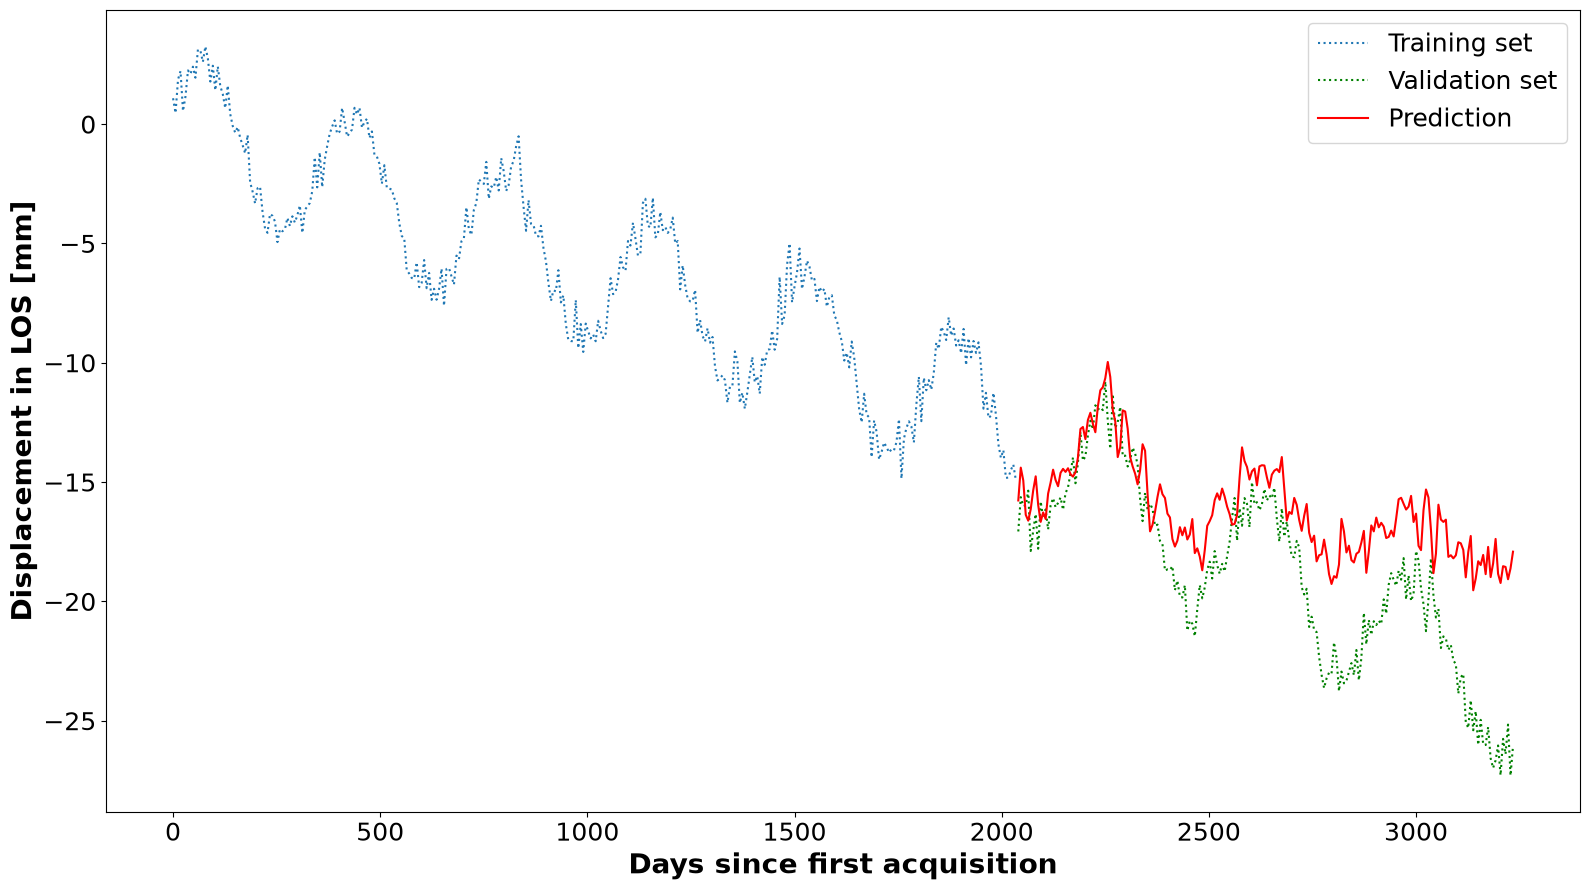

In [20]:
# Plot the train set
plt.figure(figsize=[16,9])
plt.plot(time_train, x_train, ':', label='Training set')
plt.plot(time_valid, x_valid, ':', color='green', label='Validation set')
plt.plot(time_valid, results,'-',color='red', label='Prediction')
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Days since first acquisition', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)

plt.tight_layout()
plt.show()


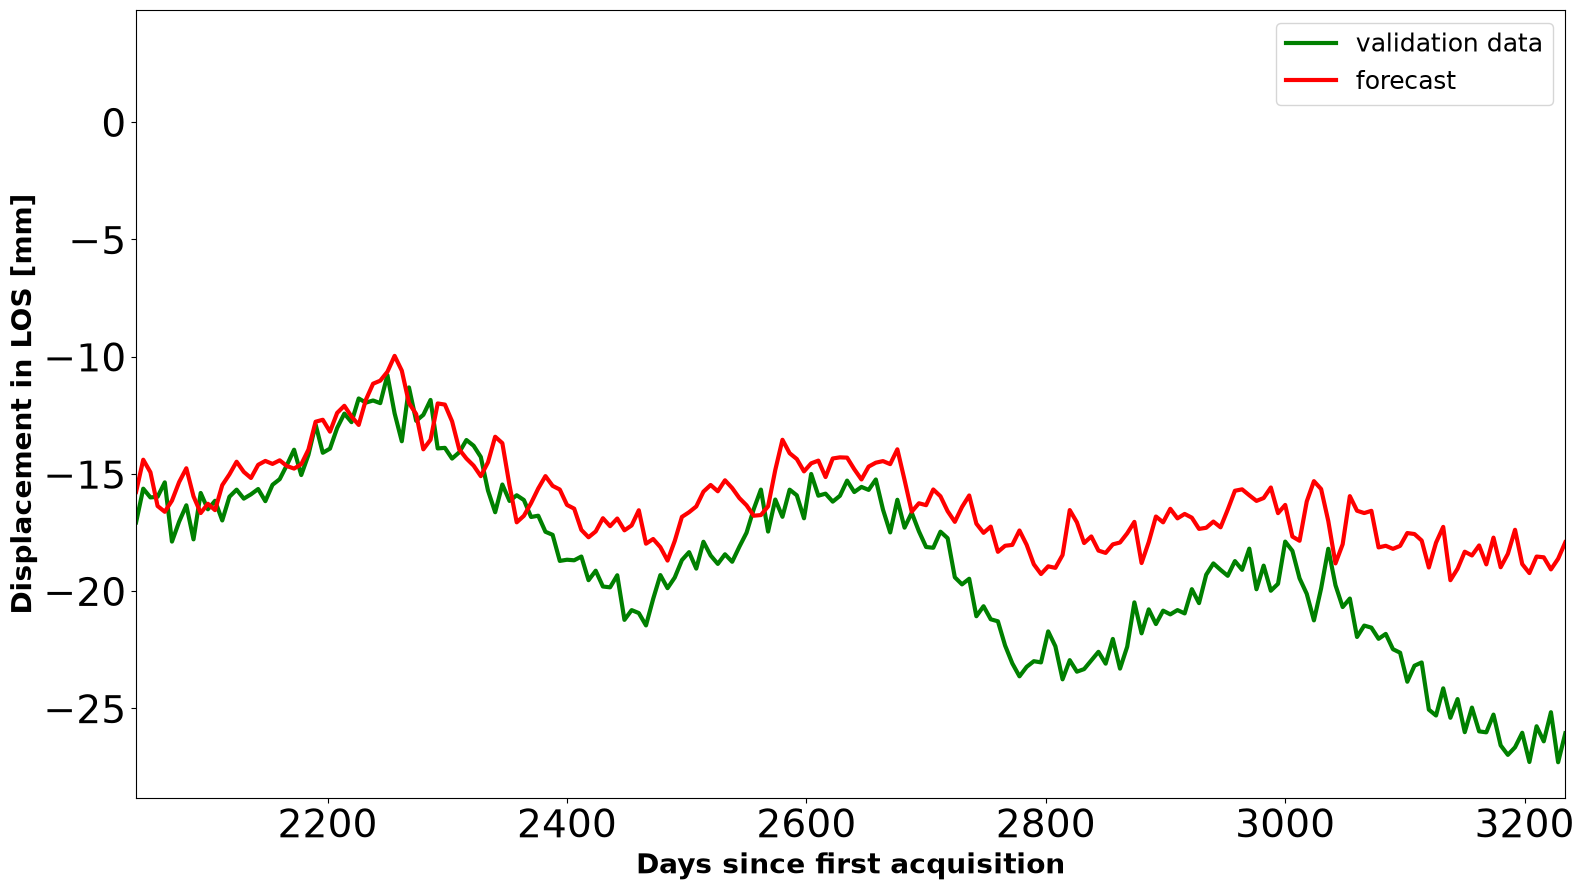

In [21]:
# Plot the train set
plt.figure(figsize=[16,9])
plt.plot(time_train, x_train)
plt.plot(time_valid, x_valid, color='green', linewidth=3, label= 'validation data')
plt.plot(time_valid, results, color='red', linewidth=3, label='forecast')
plt.legend()
plt.xlim(time_valid[0], time_valid[-1])
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Days since first acquisition', fontsize=20, fontweight='bold')
plt.xticks(fontsize=28)
plt.yticks(fontsize=28)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()


In [22]:
def forecast_metrics(actual, predicted):
    error = np.asarray(predicted) - np.asarray(actual)
    return {'MSE_mm2': float(np.mean(error ** 2)), 'MAE_mm': float(np.mean(np.abs(error)))}

persistence = this_signal[split_time - 1:-1]
rolling_metrics = pd.DataFrame({
    'Model one-step': forecast_metrics(x_valid, results),
    'Persistence one-step': forecast_metrics(x_valid, persistence),
}).T
rolling_metrics


,MSE_mm2,MAE_mm
Model one-step,12.739494,2.851402
Persistence one-step,0.877296,0.766841


## Recursive forecasts

Start with the last training window and feed each prediction into the next input.
No validation measurements are used. This is a different task from rolling
one-step prediction, and errors may grow across the horizon.


In [23]:
native_forecast = []
native_forecast_window = this_signal[split_time - window_size:split_time].copy()
for _ in range(len(x_valid)):
    next_value = float(predict_windows(native_forecast_window[None, :])[0])
    native_forecast.append(next_value)
    native_forecast_window = np.concatenate([
        native_forecast_window[1:], np.array([next_value], dtype=np.float32)
    ])
native_results = np.asarray(native_forecast, dtype=np.float32)
assert native_results.shape == x_valid.shape


In [24]:
mse = (native_results - x_valid) ** 2


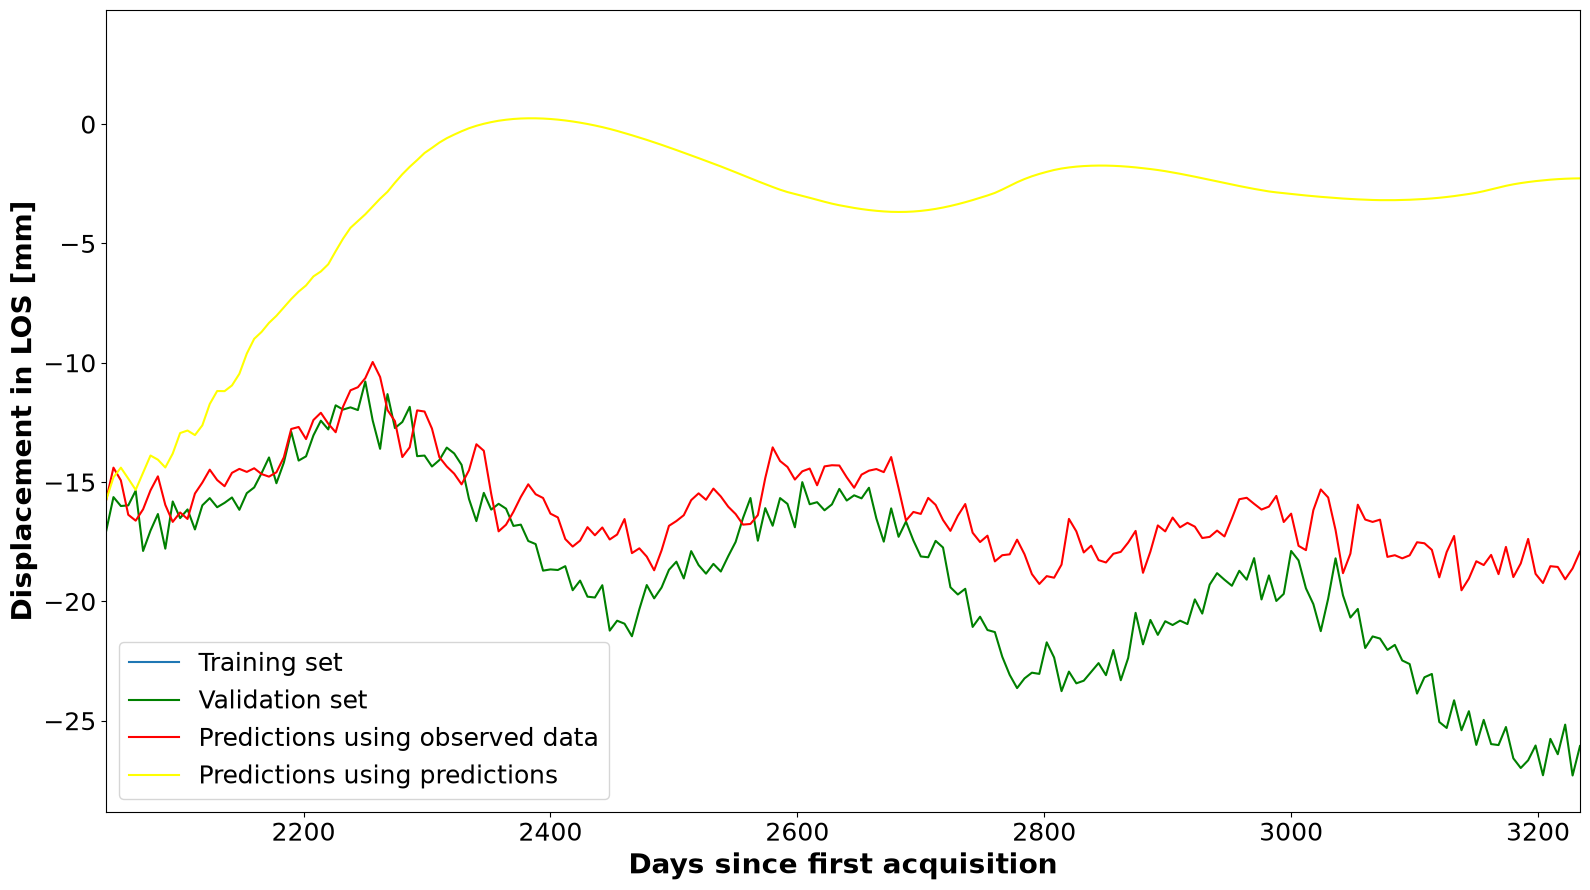

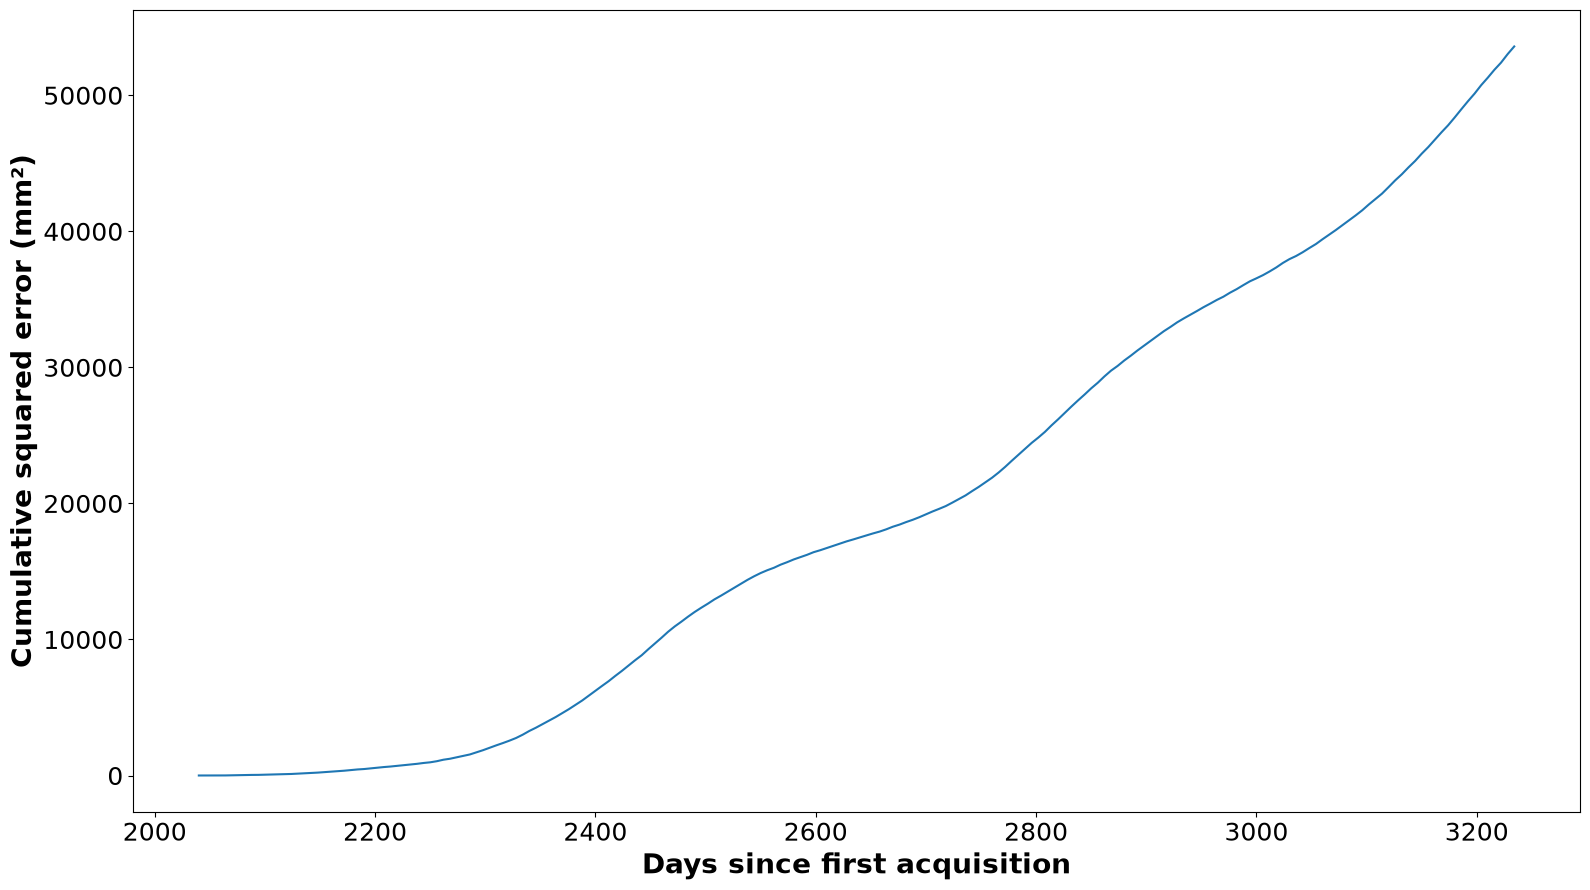

In [25]:
# Plot the train set
plt.figure(figsize=[16,9])
plt.plot(time_train, x_train, label='Training set')
plt.plot(time_valid, x_valid, color='green', label= 'Validation set')
plt.plot(time_valid, results, color='red', label='Predictions using observed data')
plt.plot(time_valid, native_results, color='yellow', label='Predictions using predictions')
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Days since first acquisition', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
plt.xlim(time_valid[0], time_valid[-1])

plt.tight_layout()
plt.show()

plt.figure(figsize=[16,9])
plt.plot(time_valid, np.cumsum(mse))
plt.ylabel('Cumulative squared error (mm²)', fontsize = 20, fontweight='bold')
plt.xlabel('Days since first acquisition', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18);
plt.yticks(fontsize=18);

plt.tight_layout()
plt.show()


Interpret the scores and plots from this run rather than carrying over the original
presentation's conclusions about forecast duration. Compare both modes against
their persistence baselines; a smooth prediction alone does not establish skill.


In [26]:
recursive_persistence = np.full_like(x_valid, x_train[-1])
recursive_metrics = pd.DataFrame({
    'Model recursive': forecast_metrics(x_valid, native_results),
    'Persistence fixed origin': forecast_metrics(x_valid, recursive_persistence),
}).T
recursive_metrics


,MSE_mm2,MAE_mm
Model recursive,267.929230,15.237685
Persistence fixed origin,29.741371,4.409268
